In [3]:
# Optional: run once if dependencies are missing in current kernel.
# You can uncomment the pip lines if needed.
# %pip install anndata scanpy torch torch-geometric torchcfm torchdyn tqdm matplotlib
from __future__ import annotations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import importlib
import math
import sys
from pathlib import Path

repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from core.utils.inference import (
    bidirectional_nn_metrics,
    canonical_time_order,
    find_time_key,
    nn_of_x_in_y,
    wasserstein_distance,
)

required = [
    'anndata',
    'numpy',
    'torch',
    'matplotlib',
    'torch_geometric',
    'torchcfm',
    'torchdyn',
    # 'nicheflow',
]

missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)


SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_float32_matmul_precision('high')

if not torch.cuda.is_available():
    raise RuntimeError('未检测到 CUDA GPU。请切换到可用 GPU 的环境后再训练。')

device = torch.device('cuda:1')
print('device =', device)
print('cuda name =', torch.cuda.get_device_name(0))


device = cuda:1
cuda name = NVIDIA A800 80GB PCIe


In [4]:
# -----------------------------
# User configurable parameters
# -----------------------------
h5ad_fp = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/prista4d/prista4d_spatial_unit.h5ad')
work_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/prista4d')
work_dir.mkdir(parents=True, exist_ok=True)

coord_obsm_key = 'spatial_3d_unit'


In [5]:
adata = ad.read_h5ad(h5ad_fp)
print('adata shape:', adata.shape)
print('obsm keys:', list(adata.obsm.keys()))

# Map user-provided spatial coordinates to the expected key.
# Gene features are read directly from adata.X by InfiniteGlobalRPCDataset.
adata.obsm['spatial'] = np.asarray(adata.obsm[coord_obsm_key], dtype=np.float32)

timepoint_col = 'time'
cell_type_col = 'anno'

if str(adata.obs[cell_type_col].dtype) != 'category':
    adata.obs[cell_type_col] = adata.obs[cell_type_col].astype('category')

timepoints_ordered = canonical_time_order(adata.obs[timepoint_col].dropna().unique())

print('timepoint column:', timepoint_col)
print('cell type column:', cell_type_col)
print('ordered timepoints:', timepoints_ordered)


adata shape: (90263, 2000)
obsm keys: ['spatial_3d', 'spatial_3d_unit']
timepoint column: time
cell type column: anno
ordered timepoints: [np.float64(0.0), np.float64(0.4), np.float64(1.1), np.float64(2.1), np.float64(3.6), np.float64(5.0), np.float64(7.1), np.float64(10.0)]


In [19]:
adata_subset.obs['timepoint'].unique()

['0hpa1', '12hpa1', '36hpa1']
Categories (3, object): ['0hpa1', '12hpa1', '36hpa1']

## Interpolation-CFM (real t0 source + velocity field supervision)

This section trains a new model with:
1. source state from real t0 data,
2. input as interpolation state between t0 and t1,
3. target as instantaneous velocity field from the interpolation path derivative.

In [57]:
import importlib

import torch

ds_mod = importlib.import_module("core.datasets.model_dataset")
stfateflow_collate = ds_mod.stfateflow_collate

stfateflowdataset = ds_mod.STFateFlowDataset

dataset_name = "prista4d"
fgw_alpha = 0.5
pi_cache_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis')
pi_cache_path = pi_cache_dir / f'fgwot_pi_{dataset_name}_alpha{fgw_alpha}_gene_triu.npz'
size_per_slice = 4096

#0.0, 0.4, 1.1, 2.1, 3.6, 5.0, 7.1, 10.0

test_timepoint = 7.1
source_timepoint = 5.0
target_timepoint = 10.0
time_str = adata[adata.obs['time'] == test_timepoint].obs['timepoint'].unique()[0]
adata_subset = adata[adata.obs['time'] <= target_timepoint]
adata_subset = adata_subset[adata_subset.obs['time'] >= source_timepoint]
timepoints_ordered = canonical_time_order(adata_subset.obs[timepoint_col].dropna().unique())

In [58]:
dataset = stfateflowdataset(
    adata=adata_subset,
    timepoint_column=timepoint_col,
    cell_type_column=cell_type_col,
    timepoints_ordered=timepoints_ordered,
    seed=SEED,
    size_per_slice=size_per_slice,
    ot_plan_cache_path= pi_cache_path,
    ot_plan_normalize=True,
    test_timepoint=test_timepoint,
)

train_num_workers = 4
batch_size = 2
train_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    num_workers=train_num_workers,
    pin_memory=True,
    persistent_workers=(train_num_workers > 0),
    collate_fn=stfateflow_collate,
)

In [60]:
import importlib

pc_vf_mod = importlib.import_module("core.models.backbones.pc_transformer")
flow_mod = importlib.import_module("core.models.STFateFlow")

# pc_vf_mod = importlib.reload(pc_vf_mod)
# flow_mod = importlib.reload(flow_mod)
# ds_mod = importlib.reload(ds_mod)

PointCloudTransformer = pc_vf_mod.PointCloudTransformer
stfateflow_model = flow_mod.STFateFlow_Module

num_steps_ode = 20
# Mixed precision on GPU: 'bf16' or 'fp16'
amp_dtype = 'bf16'

flow_ckpt_fp = work_dir / f'prista4d_gene_interp_{time_str}.pt'
lambda_features=0.1
lambda_pos=1.0
lambda_cdm=10.0

n_genes = adata.n_vars
n_slices = len(timepoints_ordered)

backbone = PointCloudTransformer(
    gene_dim=n_genes,
    coord_dim=3
)

stfateflow = stfateflow_model(
    lambda_features=lambda_features,
    lambda_pos=lambda_pos,
    lambda_cdm=lambda_cdm,
    backbone=backbone,
    num_steps=num_steps_ode,
    spatial_loss_type="l1"
).to(device)

# Training hyperparameters
lr = 3e-4
weight_decay = 1e-5
max_grad_norm = 1.0
optimizer = torch.optim.AdamW(stfateflow.parameters(), lr=lr, weight_decay=weight_decay)

autocast_dtype = torch.bfloat16 if amp_dtype == 'bf16' else torch.float16
use_scaler = amp_dtype == 'fp16'
scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
print('lr =', lr, 'max_grad_norm =', max_grad_norm, 'amp_dtype =', amp_dtype, 'use_scaler =', use_scaler)


lr = 0.0003 max_grad_norm = 1.0 amp_dtype = bf16 use_scaler = False


/data/yuz/tmp/ipykernel_2139886/2391391201.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)


Training STFateFlow (balanced):   0%|          | 0/4000 [00:00<?, ?it/s]

Saved STFateFlow checkpoint: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/prista4d/prista4d_gene_interp_10dpa1.pt


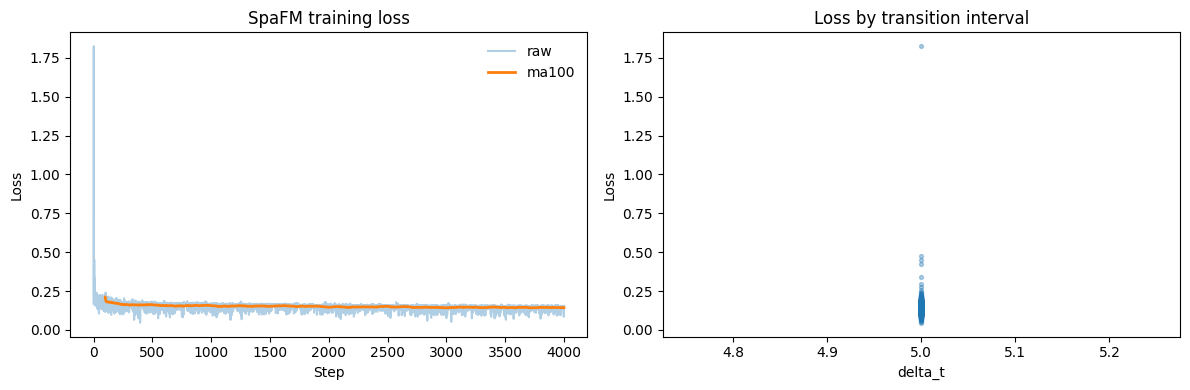

In [61]:
stfateflow.train()
stfateflow_iter = iter(train_loader)
stfateflow_loss_hist = []
stfateflow_diag_hist = []
train_steps = 1000
stfateflow_pbar = tqdm(range(train_steps), desc='Training STFateFlow (balanced)')
for step in stfateflow_pbar:

    batch = next(stfateflow_iter)
    batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(device_type='cuda', dtype=autocast_dtype, enabled=True):
        losses = stfateflow.loss(batch)
        loss = losses['loss']

    if use_scaler:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        optimizer.step()

    stfateflow_loss_hist.append(float(loss.detach().cpu()))
    stfateflow_diag_hist.append(
        {
            'loss': float(loss.detach().cpu()),
            'loss_x': float(losses['loss_x'].detach().cpu()),
            'loss_pos': float(losses['loss_pos'].detach().cpu()),
            'loss_cdm': float(losses['loss_cdm'].detach().cpu()),
            'weighted_loss_cdm': float(losses['weighted_loss_cdm'].detach().cpu()),
            'weighted_loss_pos': float(losses['weighted_loss_pos'].detach().cpu()),
            'pred_vx_norm': float(losses['pred_vx_norm'].detach().cpu()),
            'pred_vpos_norm': float(losses['pred_vpos_norm'].detach().cpu()),
            'target_vx_norm': float(losses['target_vx_norm'].detach().cpu()),
            'target_vpos_norm': float(losses['target_vpos_norm'].detach().cpu()),
            'grad_norm': float(torch.as_tensor(grad_norm).detach().cpu()),
            'delta_t': float(batch['delta_t'].mean().detach().cpu()),
            't0_raw': tuple(float(v) for v in batch['t0_raw'].detach().cpu().tolist()),
            't1_raw': tuple(float(v) for v in batch['t1_raw'].detach().cpu().tolist()),
        }
    )
    if (step + 1) % 50 == 0:
        stfateflow_pbar.set_postfix(
            {
                'loss': f"{stfateflow_loss_hist[-1]:.4f}",
                'pred_pos_v': f"{stfateflow_diag_hist[-1]['pred_vpos_norm']:.4g}",
                'target_pos_v': f"{stfateflow_diag_hist[-1]['target_vpos_norm']:.4g}",
                'cdm': f"{stfateflow_diag_hist[-1]['loss_cdm']:.4g}",
                'w_cdm': f"{stfateflow_diag_hist[-1]['weighted_loss_cdm']:.4g}",
                'grad': f"{stfateflow_diag_hist[-1]['grad_norm']:.3g}",
            }
        )

torch.save(
    {
        'flow_state_dict': stfateflow.state_dict(),
        'n_genes': n_genes,
        'n_slices': n_slices,
        'timepoints_ordered': timepoints_ordered,
        'config': {
            'model': 'STFateFlow_khead_balanced',
            'size_per_slice': size_per_slice,
            'train_steps': train_steps,
            'lr': lr,
            'weight_decay': weight_decay,
            'max_grad_norm': max_grad_norm,
            'amp_dtype': amp_dtype,
            'num_steps_ode': num_steps_ode,
            'lambda_features': lambda_features,
            'lambda_pos': lambda_pos,
            'lambda_cdm': lambda_cdm,
            'spatial_loss_type': stfateflow.spatial_loss_type,
        },
    },
    flow_ckpt_fp,
)
print('Saved STFateFlow checkpoint:', flow_ckpt_fp)

loss_arr = np.asarray(stfateflow_loss_hist, dtype=np.float64)
window = min(100, max(1, len(loss_arr)))
ma = np.convolve(loss_arr, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_arr, alpha=0.35, label='raw')
axes[0].plot(np.arange(window - 1, window - 1 + len(ma)), ma, linewidth=2, label=f'ma{window}')
axes[0].set_title('STFateFlow training loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=False)

diag_delta_t = np.asarray([d['delta_t'] for d in stfateflow_diag_hist], dtype=np.float64)
axes[1].scatter(diag_delta_t, loss_arr, s=8, alpha=0.35)
axes[1].set_title('Loss by transition interval')
axes[1].set_xlabel('delta_t')
axes[1].set_ylabel('Loss')
plt.tight_layout()
plt.show()


In [62]:
ds_mod = importlib.reload(ds_mod)

stfateflow.eval()
stfateflow.num_steps = 20
size_per_slice = 4096

interpolation_timepoint = test_timepoint

t1_key = find_time_key(timepoints_ordered, source_timepoint)
t2_key = find_time_key(timepoints_ordered, target_timepoint)

source_pc = dataset.timepoint_pc[t1_key]
target_pc = dataset.timepoint_pc[t2_key]

X_t0 = source_pc.x.unsqueeze(0).to(device)
pos_t0 = source_pc.pos.unsqueeze(0).to(device)

n_cells = X_t0.size(1)
sample_t_start = float(source_pc.t_value.item())
sample_t_end = float(target_pc.t_value.item()) if interpolation_timepoint < 0 else float(interpolation_timepoint) - dataset.time_origin
print('sample_t_start =', sample_t_start, 'sample_t_end =', sample_t_end)

with torch.no_grad():
    sample_out = stfateflow.sample(
        X_t0=X_t0,
        pos_t0=pos_t0,
        t_start=sample_t_start,
        t_end=sample_t_end,
    )

    # Compatible with both return styles:
    # 1) tuple/list: (x_traj, pos_traj)
    # 2) dict: {'x_traj': ..., 'pos_traj': ...}
    if isinstance(sample_out, dict):
        x_traj = sample_out.get('x_traj', None)
        pos_traj = sample_out.get('pos_traj', None)
        potential_traj = sample_out.get('potential_traj', None)

    last_x = x_traj[-1] if isinstance(x_traj, (list, tuple)) else x_traj
    last_pos = pos_traj[-1] if isinstance(pos_traj, (list, tuple)) else pos_traj

    pred_x_interp = last_x.reshape(-1, n_genes).detach().cpu().numpy()
    coord_dim = int(pos_t0.shape[-1])
    pred_pos_interp = last_pos.reshape(-1, coord_dim).detach().cpu().numpy()

# Source potential/velocity visualization is in the next cell.
import anndata as ad
output_dir = '/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/experiments/results/'
test_adata = adata[adata.obs['time'] == interpolation_timepoint]
pred_adata = ad.AnnData(X=pred_x_interp)
pred_adata.obsm['pred_spatial'] = pred_pos_interp
time_str = adata_subset[adata_subset.obs['time'] == interpolation_timepoint].obs['timepoint'].unique()[0]
output_file = f'PRISTA4D_stfateflow_interpolated_time_{time_str}.h5ad'
output_path = output_dir + output_file
pred_adata.write_h5ad(output_path)

sample_t_start = 0.0 sample_t_end = 2.0999999999999996


2026-07-18 22:33:03.714 (   0.779s) [    7D92EB508740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


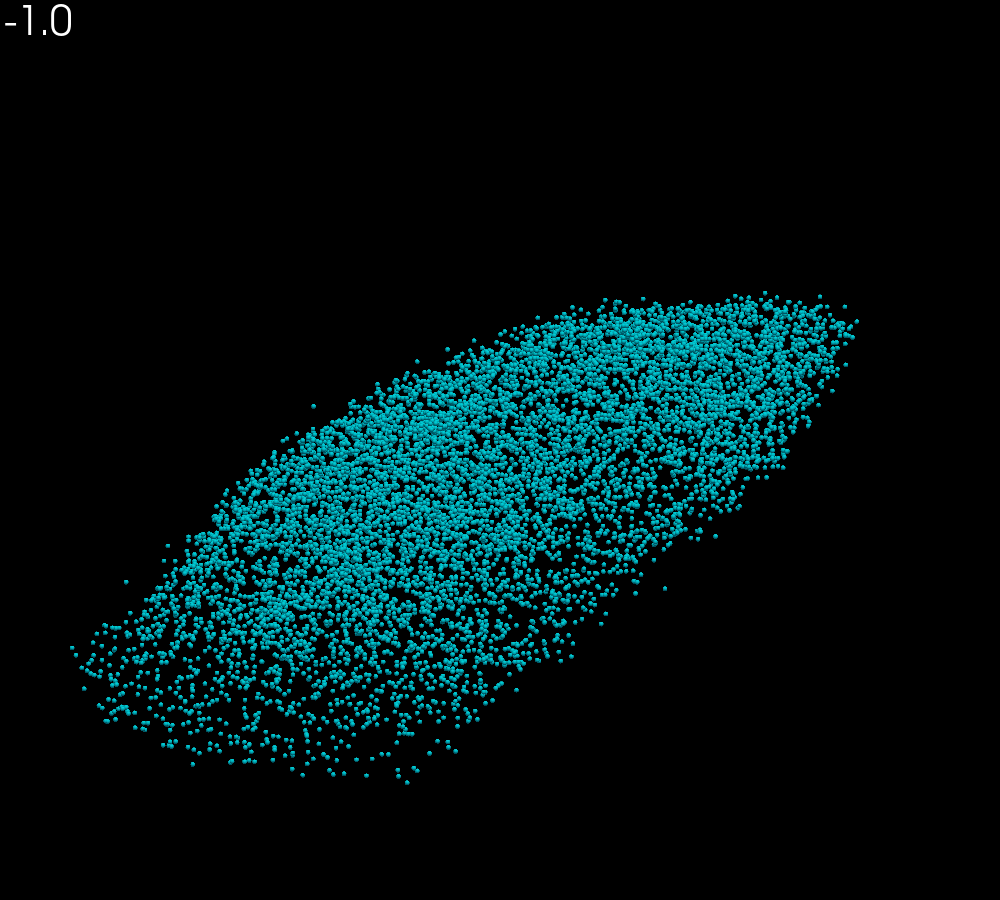

In [9]:
#visualize interpolation
import pyvista as pv

def _to_3d(points: np.ndarray) -> np.ndarray:
    if points.shape[1] >= 3:
        return points[:, :3]
    z = np.zeros((points.shape[0], 1), dtype=points.dtype)
    return np.concatenate([points[:, :2], z], axis=1)

interp_cloud = pv.PolyData(pred_pos_interp)

try:
    pv.set_jupyter_backend('static')
except Exception:
    pass

pl = pv.Plotter(notebook=True, window_size=(1000, 900))
pl.set_background('black')
pl.add_points(interp_cloud, color='#00e5ff', point_size=5, render_points_as_spheres=True)
pl.add_text(f'{interpolation_timepoint}', font_size=16, color='white')
# pl.hide_axes()
pl.reset_camera()
pl.camera.zoom(1.25)

screenshot_path = work_dir / f'prista4d_{interpolation_timepoint}.png'
pl.show(screenshot=str(screenshot_path))

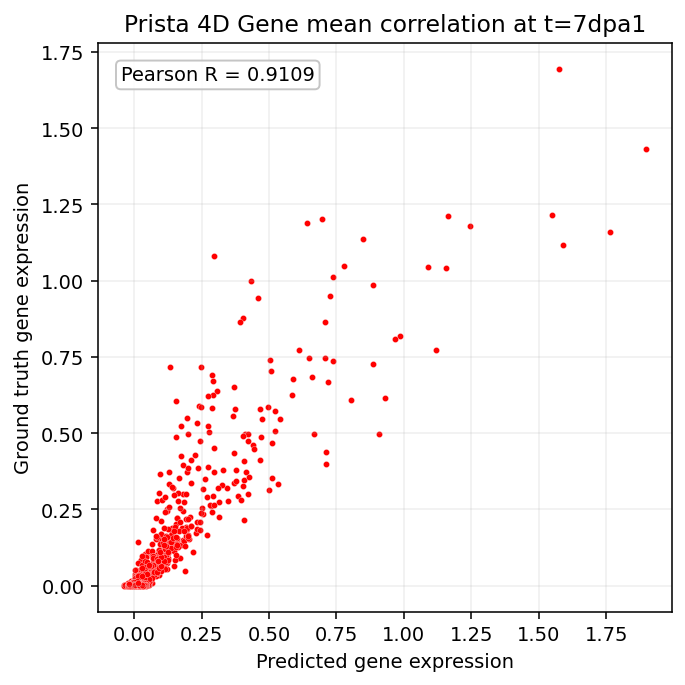

In [10]:
def normalize_coords_by_gt(pred_pos, gt_pos, eps=1e-8):
    gt_center = gt_pos.mean(axis=0, keepdims=True)
    gt_scale = np.linalg.norm(gt_pos - gt_center, axis=1).mean()
    
    pred_norm = (pred_pos - gt_center) / (gt_scale + eps)
    gt_norm = (gt_pos - gt_center) / (gt_scale + eps)

    return pred_norm, gt_norm

t2_key = interpolation_timepoint if interpolation_timepoint >= 0 else t2_key

t2_str = adata[adata.obs['time'] == t2_key].obs['time_str'].unique()[0]

source_x = dataset.timepoint_pc[t1_key].x.detach().cpu().numpy()
source_pos = dataset.timepoint_pc[t1_key].pos.detach().cpu().numpy()

gt_x_interp = dataset.timepoint_pc[t2_key].x.detach().cpu().numpy()
gt_pos_interp = dataset.timepoint_pc[t2_key].pos.detach().cpu().numpy()

pred_gene_mean = pred_x_interp.mean(axis=0)
gt_gene_mean = gt_x_interp.mean(axis=0)
valid_gene_mask = np.isfinite(pred_gene_mean) & np.isfinite(gt_gene_mean)
pred_gene_mean_valid = pred_gene_mean[valid_gene_mask]
gt_gene_mean_valid = gt_gene_mean[valid_gene_mask]

if pred_gene_mean_valid.size < 2 or np.std(pred_gene_mean_valid) == 0 or np.std(gt_gene_mean_valid) == 0:
    gene_mean_pearson = np.nan
else:
    gene_mean_pearson = float(np.corrcoef(pred_gene_mean_valid, gt_gene_mean_valid)[0, 1])

fig, ax = plt.subplots(figsize=(5, 5), dpi=140)
ax.scatter(
    pred_gene_mean_valid,
    gt_gene_mean_valid,
    s=10,
    color='#ff0000',
    # alpha=0.55,
    edgecolors='white',
    linewidths=0.15,
)
ax.set_xlabel('Predicted gene expression')
ax.set_ylabel('Ground truth gene expression')
ax.set_title(f'Prista 4D Gene mean correlation at t={t2_str}')
ax.text(
    0.04,
    0.96,
    f'Pearson R = {gene_mean_pearson:.4f}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.75', alpha=0.9),
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [11]:
pred_pos_interp, gt_pos_interp = normalize_coords_by_gt(pred_pos_interp, gt_pos_interp)

pred_pos_t = torch.tensor(pred_pos_interp, dtype=torch.float32)
gt_pos_t = torch.tensor(gt_pos_interp, dtype=torch.float32)
coord_metrics = bidirectional_nn_metrics(pred_pos_t, gt_pos_t)
idx_pred_to_gt_interp_t = coord_metrics['idx_x_to_y']
dist_pred_to_gt_interp_t = coord_metrics['dist_x_to_y']
idx_pred_to_gt_interp = idx_pred_to_gt_interp_t.detach().cpu().numpy()
dist_pred_to_gt_interp = dist_pred_to_gt_interp_t.detach().cpu().numpy()

matched_gt_x_interp = gt_x_interp[idx_pred_to_gt_interp]

from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

chamfer_interp = float(coord_metrics['cd_sq'].detach().cpu())
chamfer_l2_interp = float(coord_metrics['cd_l2'].detach().cpu())
chamfer_rmse_interp = float(coord_metrics['cd_rmse'].detach().cpu())
hausdorff95_interp = float(coord_metrics['hd95'].detach().cpu())
hausdorff_interp = float(coord_metrics['hd'].detach().cpu())

pos_interp_wass = float(
    wasserstein_distance(
        torch.tensor(gt_pos_interp, dtype=torch.float32),
        torch.tensor(pred_pos_interp, dtype=torch.float32),
        power=1,
    )
)

anno = 'anno'
target_global_indices = np.asarray(np.where(adata.obs[timepoint_col] == t2_key)[0])
gt_annotation_interp = adata.obs.iloc[target_global_indices][anno].astype(str).to_numpy()
if gt_annotation_interp.shape[0] != gt_pos_interp.shape[0]:
    n_min = min(gt_annotation_interp.shape[0], gt_pos_interp.shape[0])
    print(
        f"Warning: annotation count ({gt_annotation_interp.shape[0]}) != target cell count ({gt_pos_interp.shape[0]}), truncating to {n_min}."
    )
    gt_annotation_interp = gt_annotation_interp[:n_min]
    gt_pos_interp = gt_pos_interp[:n_min]
    gt_x_interp = gt_x_interp[:n_min]
    idx_pred_to_gt_interp_t, dist_pred_to_gt_interp_t = nn_of_x_in_y(
        torch.tensor(pred_pos_interp, dtype=torch.float32),
        torch.tensor(gt_pos_interp, dtype=torch.float32),
    )
    idx_pred_to_gt_interp = idx_pred_to_gt_interp_t.detach().cpu().numpy()
    matched_gt_x_interp = gt_x_interp[idx_pred_to_gt_interp]

matched_gt_annotation_interp = gt_annotation_interp[idx_pred_to_gt_interp]
# Temporary visualization label: nearest GT annotation, not a model prediction.
pred_annotation_interp = matched_gt_annotation_interp

ann_levels = np.unique(np.concatenate([gt_annotation_interp, pred_annotation_interp]))
ann_to_idx = {ann: i for i, ann in enumerate(ann_levels)}
gt_color_idx = np.asarray([ann_to_idx[a] for a in gt_annotation_interp], dtype=int)
pred_color_idx = np.asarray([ann_to_idx[a] for a in pred_annotation_interp], dtype=int)

n_ann = len(ann_levels)
if n_ann <= 0:
    ann_colors = np.asarray(['#ffffff'], dtype=object)
else:
    # Generate one bright color per annotation. Golden-ratio hue spacing keeps
    # neighboring annotation ids from receiving overly similar colors.
    hues = (np.arange(n_ann) * 0.618033988749895) % 1.0
    rgb = plt.cm.hsv(hues)[:, :3]
    ann_colors = 0.35 + 0.65 * rgb
ann_cmap = ListedColormap(ann_colors)
gt_point_colors = ann_colors[gt_color_idx]
pred_point_colors = ann_colors[pred_color_idx]

print(f'{source_timepoint} {t2_key} Chamfer squared: {chamfer_interp:.4f}')
print(f'{source_timepoint} {t2_key} Chamfer L2 mean: {chamfer_l2_interp:.4f}')
print(f'{source_timepoint} {t2_key} Chamfer RMSE: {chamfer_rmse_interp:.4f}')
print(f'{source_timepoint} {t2_key} Hausdorff95: {hausdorff95_interp:.4f}')
print(f'{source_timepoint} {t2_key} Hausdorff max: {hausdorff_interp:.4f}')
print(f'{source_timepoint} {t2_key} coord Wasserstein distance: {pos_interp_wass:.4f}')
print(f'annotation categories: {n_ann}')

3.6 5.0 Chamfer squared: 0.0054
3.6 5.0 Chamfer L2 mean: 0.0890
3.6 5.0 Chamfer RMSE: 0.1029
3.6 5.0 Hausdorff95: 0.1183
3.6 5.0 Hausdorff max: 0.2799
3.6 5.0 coord Wasserstein distance: 0.1102
annotation categories: 36


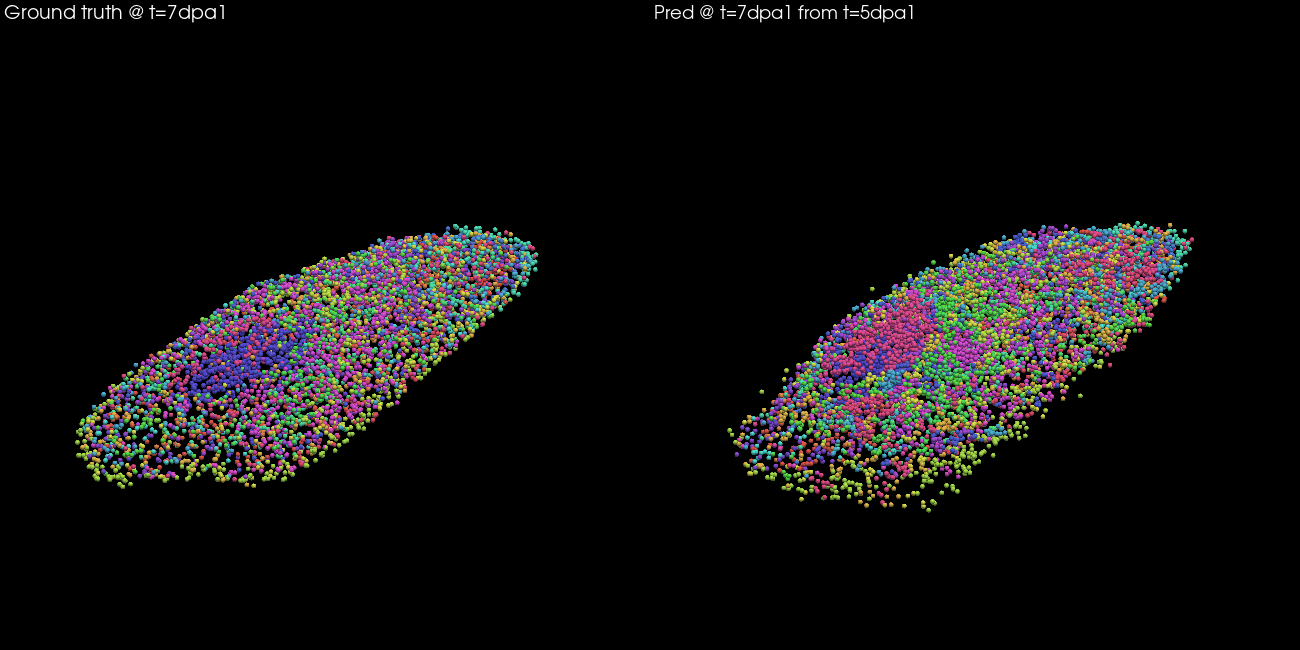

In [12]:
import pyvista as pv

def _to_3d(points: np.ndarray) -> np.ndarray:
    if points.shape[1] >= 3:
        return points[:, :3]
    z = np.zeros((points.shape[0], 1), dtype=points.dtype)
    return np.concatenate([points[:, :2], z], axis=1)

gt_points_3d = _to_3d(gt_pos_interp)
pred_points_3d = _to_3d(pred_pos_interp)

den = max(n_ann - 1, 1)
gt_rgb = (ann_cmap(gt_color_idx / den)[:, :3] * 255).astype(np.uint8)
pred_rgb = (ann_cmap(pred_color_idx / den)[:, :3] * 255).astype(np.uint8)

gt_cloud = pv.PolyData(gt_points_3d)
gt_cloud['rgb'] = gt_rgb
pred_cloud = pv.PolyData(pred_points_3d)
pred_cloud['rgb'] = pred_rgb

mode_text = 'trajectory'
try:
    pv.set_jupyter_backend('static')
except Exception:
    pass

t_curr_tp = adata[adata.obs['time']==t2_key].obs['timepoint'].unique()[0]
t_pre_tp = adata[adata.obs['time']==source_timepoint].obs['timepoint'].unique()[0]
pl = pv.Plotter(shape=(1, 2), notebook=True, window_size=(1300, 650))
pl.set_background('black')
pl.subplot(0, 0)
pl.set_background('black')
pl.add_points(gt_cloud, scalars='rgb', rgb=True, point_size=5, render_points_as_spheres=True)
pl.add_text(f'Ground truth @ t={t_curr_tp}', font_size=10, color='white')
pl.hide_axes()

pl.subplot(0, 1)
pl.set_background('black')
pl.add_points(pred_cloud, scalars='rgb', rgb=True, point_size=5, render_points_as_spheres=True)
pl.add_text(f'Pred @ t={t_curr_tp} from t={t_pre_tp}', font_size=10, color='white')
pl.hide_axes()

pl.link_views()
pl.reset_camera()
# pl.camera.zoom(1)
screenshot_path = work_dir / f'prista4d_{source_timepoint}_to_{t2_key}_potential_pos_infer.png'
pl.show(screenshot=str(screenshot_path))

In [20]:
adata.obs['time'].unique()

array([ 0. ,  0.4,  1.1,  2.1,  3.6,  5. ,  7.1, 10. ])

In [22]:
np.corrcoef(adata[adata.obs['time'] ==5.0].X.mean(axis=0), adata[adata.obs['time'] ==7.1].X.mean(axis=0))

array([[1.        , 0.95305022],
       [0.95305022, 1.        ]])

In [49]:
s = '0hpa1'
res = s[:-1]

In [52]:
adata.obs['timepoint'][0]

/data/yuz/tmp/ipykernel_2370006/3056091390.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs['timepoint'][0]


'0hpa1'

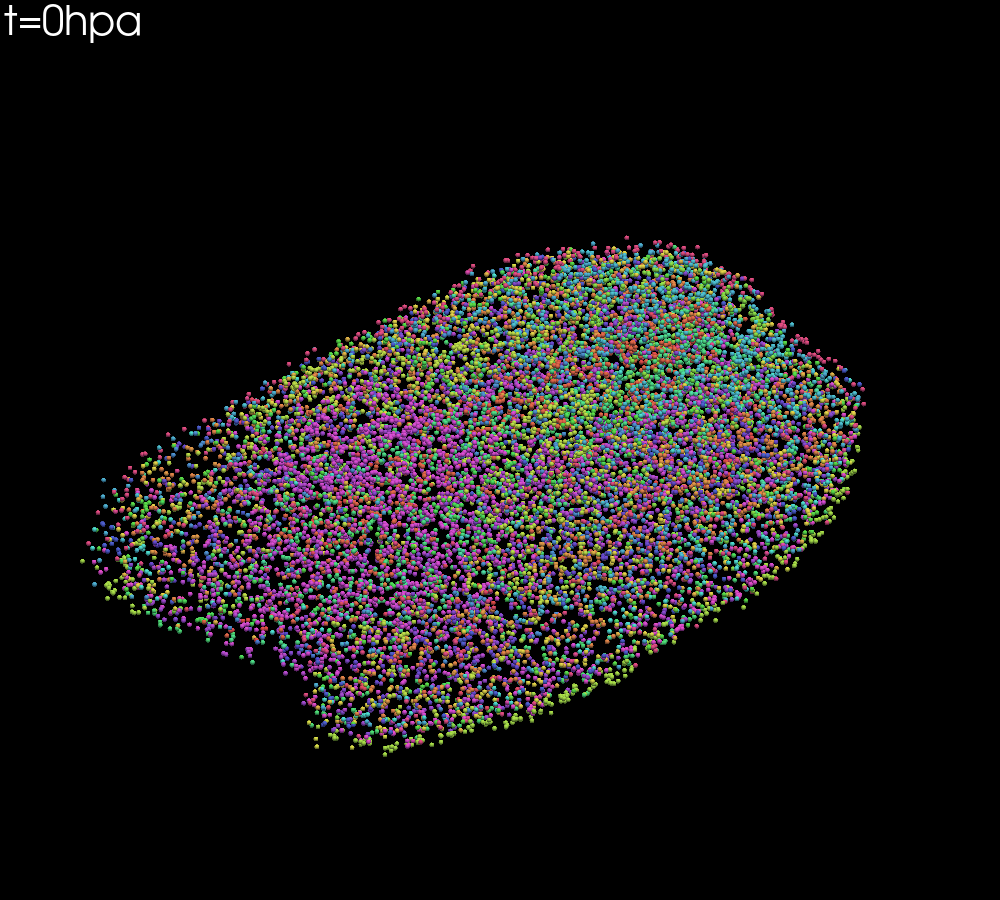

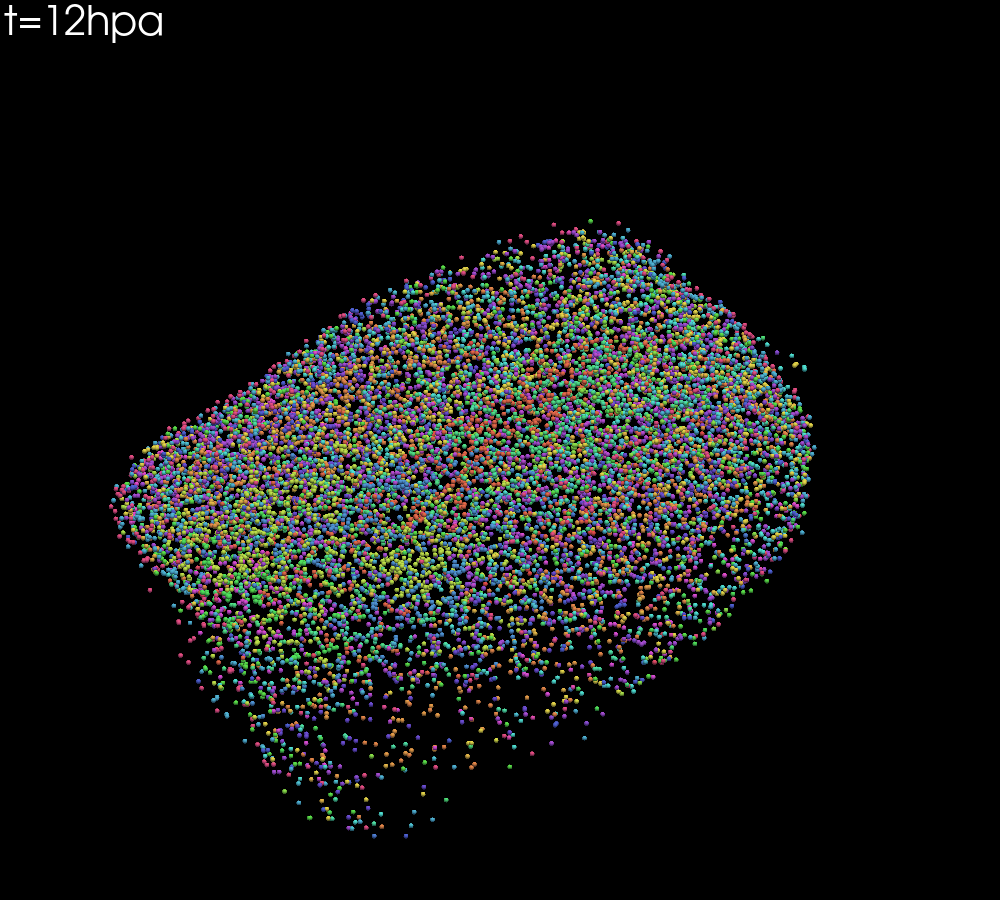

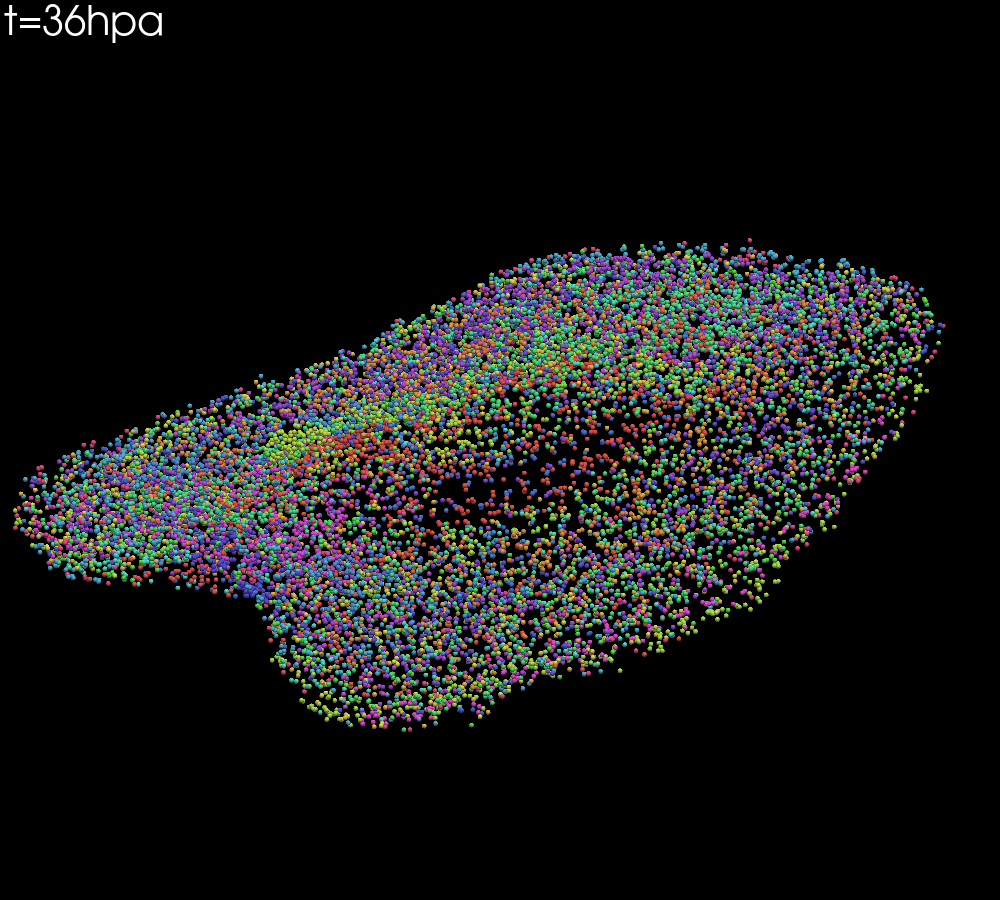

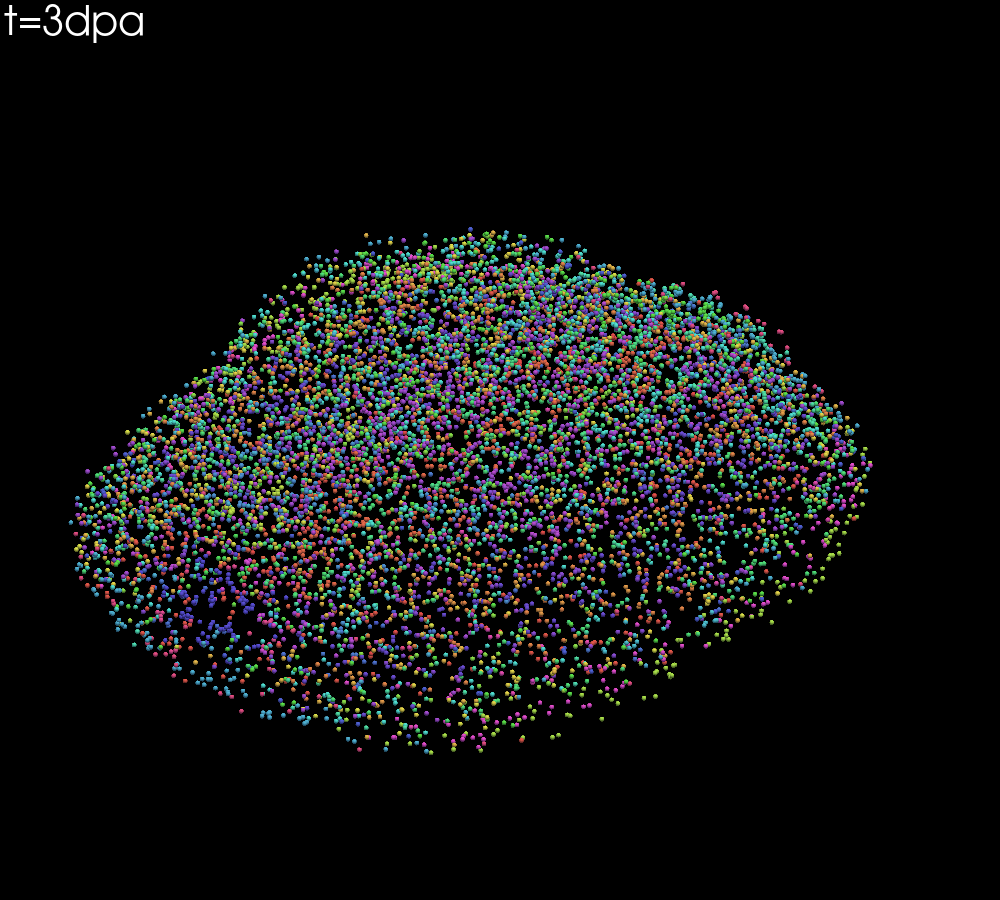

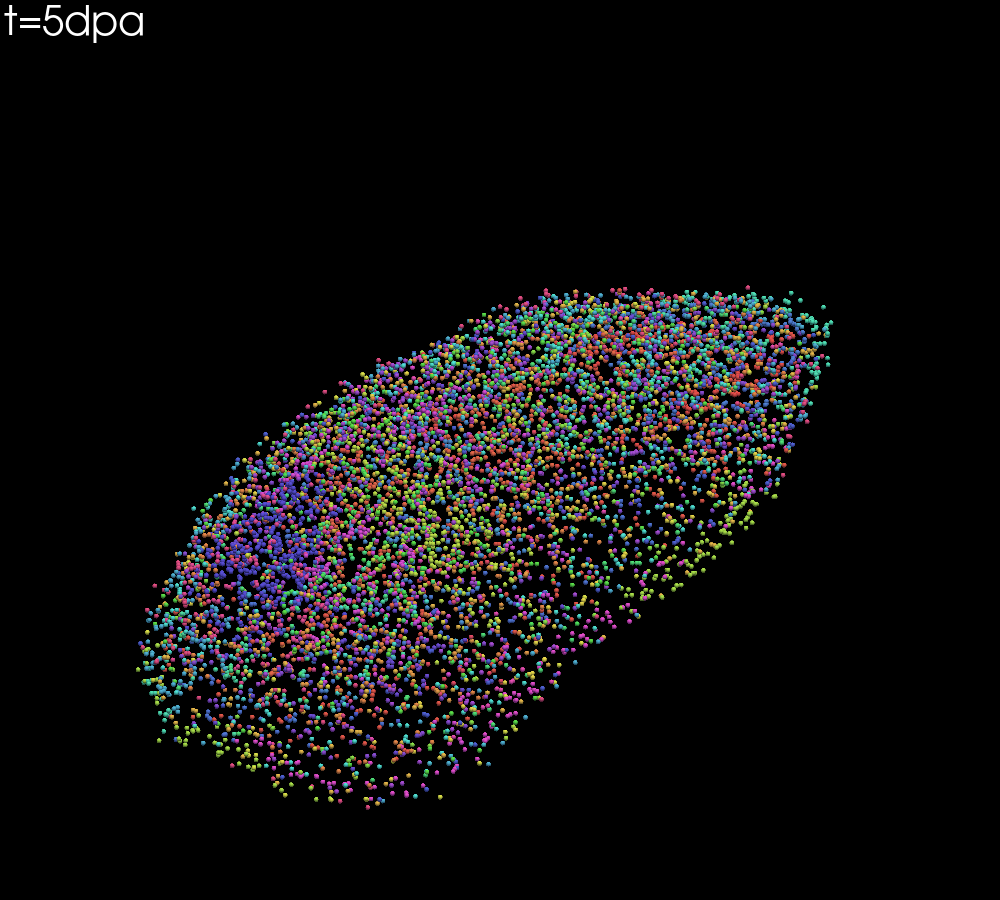

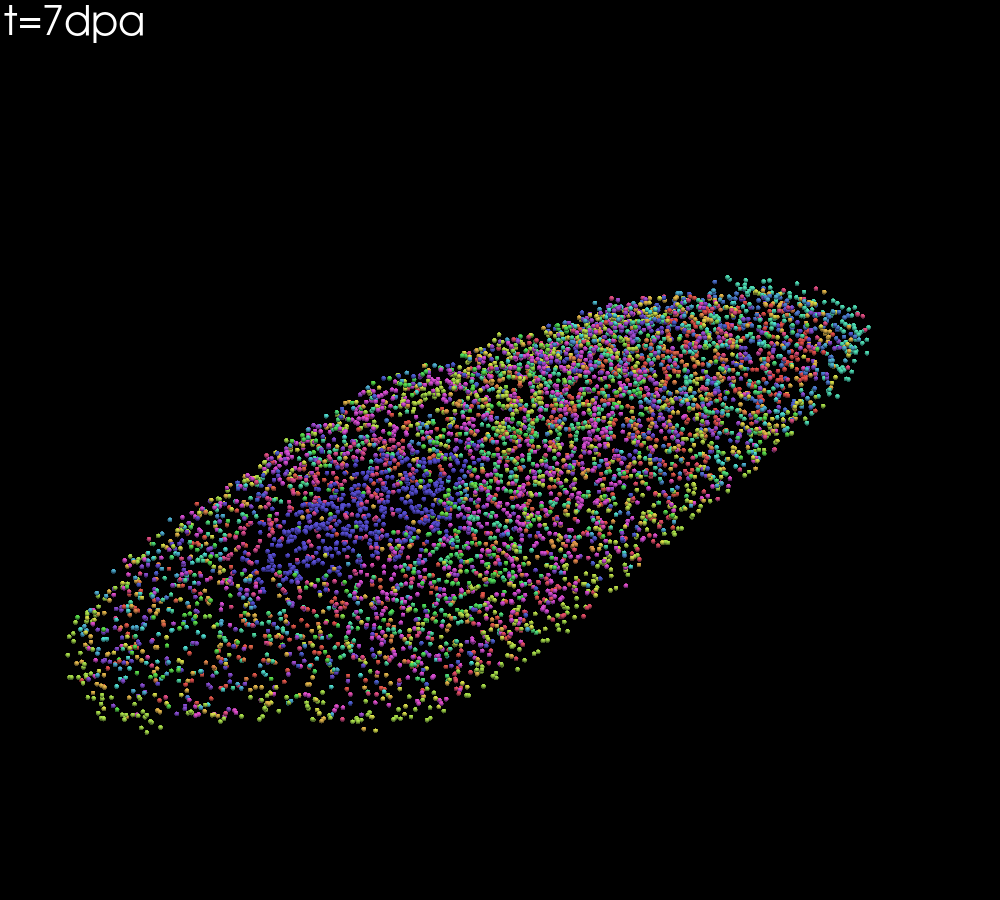

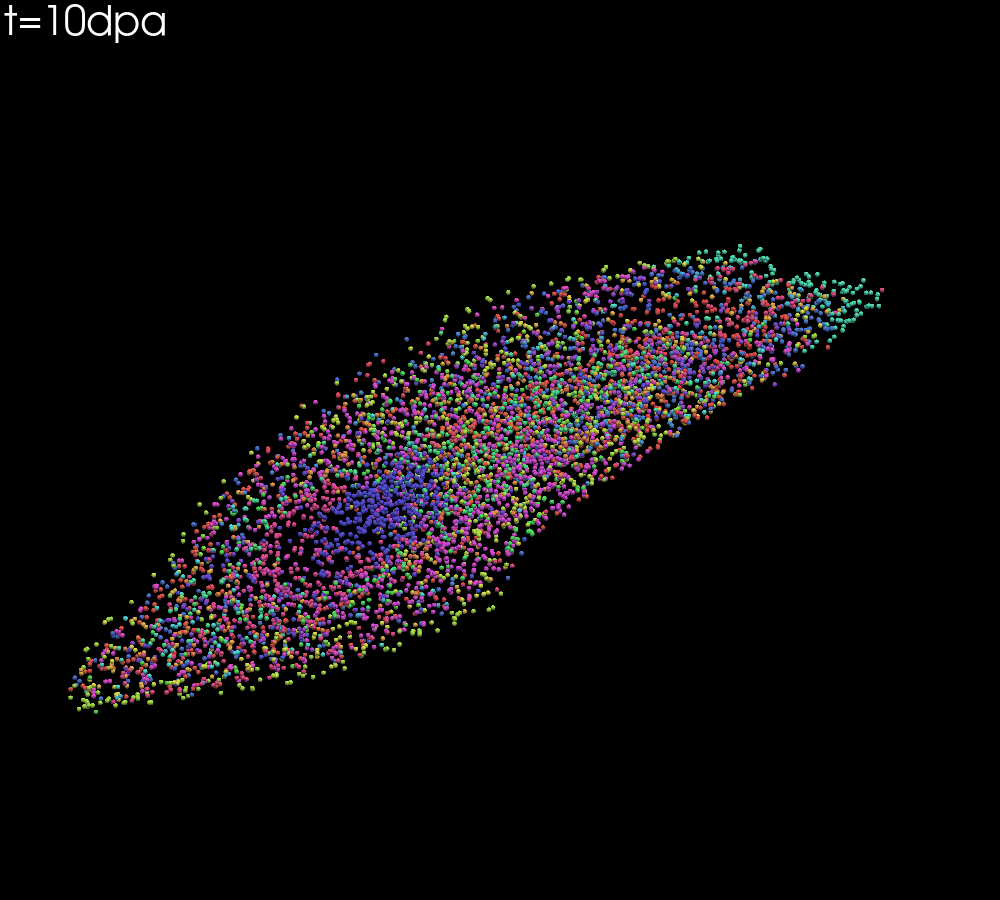

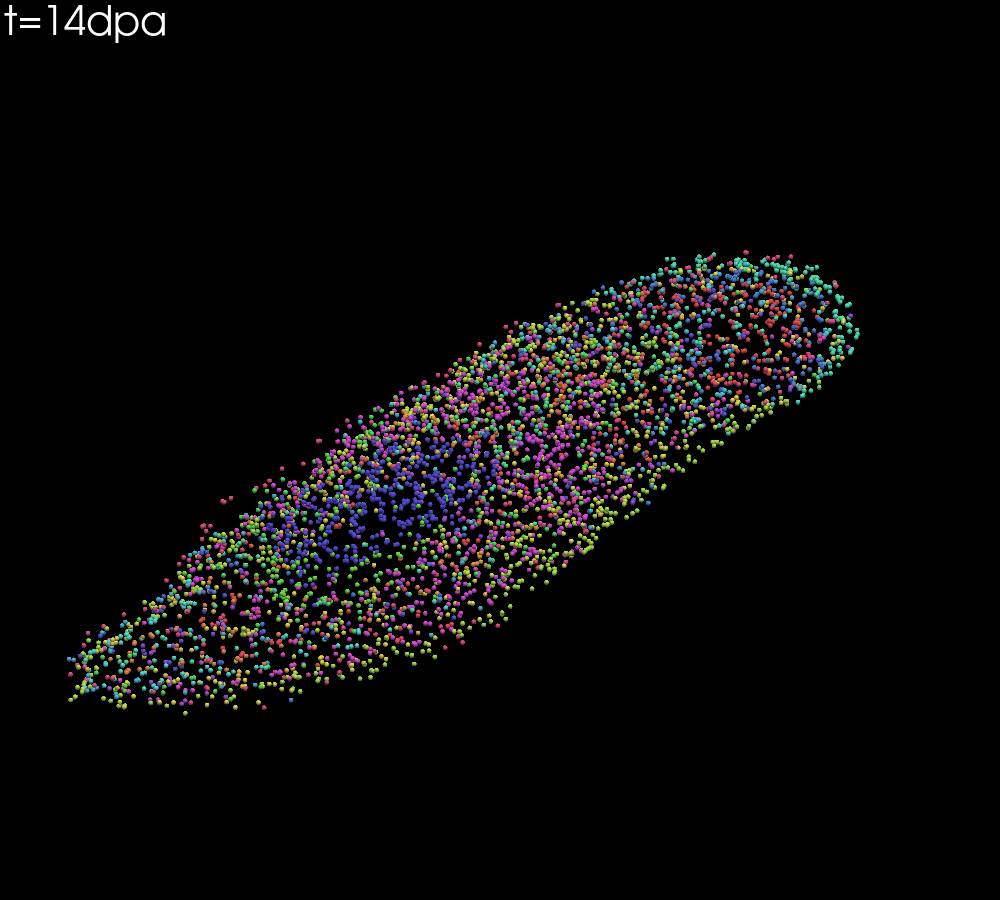

In [71]:
import pyvista as pv

def _to_3d(points: np.ndarray) -> np.ndarray:
    if points.shape[1] >= 3:
        return points[:, :3]
    z = np.zeros((points.shape[0], 1), dtype=points.dtype)
    return np.concatenate([points[:, :2], z], axis=1)

for t_curr in adata.obs['time'].unique():
    gt_pos = dataset.timepoint_pc[t_curr].pos.detach().cpu().numpy()
    gt_pos = _to_3d(gt_pos)
    
    ann_levels = np.unique(adata[adata.obs['time']==t_curr].obs['anno'])
    ann_to_idx = {ann: i for i, ann in enumerate(ann_levels)}
    gt_annotation_interp = adata[adata.obs['time']==t_curr].obs['anno'].astype(str).to_numpy()
    gt_color_idx = np.asarray([ann_to_idx[a] for a in gt_annotation_interp], dtype=int)

    n_ann = len(ann_levels)
    if n_ann <= 0:
        ann_colors = np.asarray(['#ffffff'], dtype=object)
    else:
        # Generate one bright color per annotation. Golden-ratio hue spacing keeps
        # neighboring annotation ids from receiving overly similar colors.
        hues = (np.arange(n_ann) * 0.618033988749895) % 1.0
        rgb = plt.cm.hsv(hues)[:, :3]
        ann_colors = 0.35 + 0.65 * rgb
    ann_cmap = ListedColormap(ann_colors)
    
    den = max(n_ann - 1, 1)
    gt_rgb = (ann_cmap(gt_color_idx / den)[:, :3] * 255).astype(np.uint8)

    gt_cloud = pv.PolyData(gt_pos)
    gt_cloud['rgb'] = gt_rgb

    mode_text = 'trajectory'
    try:
        pv.set_jupyter_backend('static')
    except Exception:
        pass

    t_str = adata[adata.obs['time']==t_curr].obs['timepoint'].unique()[0]
    pl = pv.Plotter(notebook=True, window_size=(1000, 900))
    pl.set_background('black')
    pl.add_points(gt_cloud, scalars='rgb', rgb=True, point_size=5, render_points_as_spheres=True)
    pl.add_text(f't={t_str}', font_size=16, color='white')
    # pl.hide_axes()
    pl.reset_camera()
    pl.camera.zoom(1.25)

    screenshot_path = work_dir / f'prista4d_{t_curr}.png'
    pl.show(screenshot=str(screenshot_path))

In [ ]:
import core.utils.cell_type_identifier as ct_mod
st_classifier_save_path = '/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/stfm/data/prista4d/anno_model_prista4d.pth'

ct_mod = importlib.reload(ct_mod)

label_to_cell_type_map = ct_mod.create_spatiotemporal_classifier(adata, 
                                st_classifier_save_path = st_classifier_save_path,
                                annotation_key='anno',
                                spatial_key='spatial_3d'
                                )


In [ ]:
def get_cell_type(cur_cell, st_classifier_path, t, label_to_cell_type_map):
    model_anno = torch.load(st_classifier_path, map_location='cpu', weights_only=False)
    model_anno.eval()
    with torch.no_grad():
        time = torch.full((cur_cell.size(0), 1), fill_value=float(t), device=cur_cell.device)
        inputs = torch.cat((cur_cell, time), dim=1)
        outputs = model_anno(inputs)
        cur_cell_label = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        # cur_cell_type = list(label_to_cell_type_map[cell_type_index])
        cur_cell_type = [label_to_cell_type_map[cell_label_i.item()] for cell_label_i in cur_cell_label]
    return cur_cell_type


In [ ]:
cell_type_traj = []
t_start = 1
for i in range(len(x_traj)):
    cur_exp = x_traj[i][0]
    cur_pos = pos_traj[i][0]
    cur_cell = torch.cat((cur_exp, cur_pos), dim=1).type(torch.float32)
    step_cell_types = get_cell_type(
        cur_cell.cpu(),
        st_classifier_save_path,
        t=i / max(len(x_traj) - 1, 1) + t_start,
        label_to_cell_type_map=label_to_cell_type_map
    )
    cell_type_traj.append(step_cell_types)

# cur_time = torch.full((cur_exp.size(0), 1), fill_value=float(0.0), device=cur_exp.device)


In [ ]:
# 随机抽取一个中间时间点（非起点/终点）并可视化，颜色来自该步注释结果
import numpy as np
import pyvista as pv

if 'x_traj' not in globals() or 'pos_traj' not in globals() or 'cell_type_traj' not in globals():
    raise RuntimeError('请先运行上一单元，确保 x_traj / pos_traj / cell_type_traj 已生成。')

n_steps = len(x_traj)
if n_steps == 0:
    raise RuntimeError('x_traj 为空，无法可视化。')

# 优先从中间步随机抽取
if n_steps >= 3:
    candidate_steps = np.arange(1, n_steps - 1)
else:
    candidate_steps = np.arange(n_steps)

rng = np.random.default_rng(SEED)
step_idx = int(rng.choice(candidate_steps))

cur_pos = pos_traj[step_idx][0].detach().cpu().numpy()
cur_types = np.asarray(cell_type_traj[step_idx])
if cur_pos.shape[0] != cur_types.shape[0]:
    raise ValueError(
        f'细胞数不一致：pos={cur_pos.shape[0]}, annotation={cur_types.shape[0]}。'
    )

# 统一到 3D 坐标用于 pyvista 展示
if cur_pos.shape[1] >= 3:
    pts = cur_pos[:, :3]
else:
    pts = np.concatenate([cur_pos[:, :2], np.zeros((cur_pos.shape[0], 1), dtype=cur_pos.dtype)], axis=1)

type_levels = np.unique(cur_types)
type_to_idx = {k: i for i, k in enumerate(type_levels)}
idx = np.asarray([type_to_idx[t] for t in cur_types], dtype=np.int32)

if len(type_levels) <= 20:
    cmap = plt.get_cmap('tab20', max(len(type_levels), 1))
else:
    cmap = plt.get_cmap('gist_ncar', len(type_levels))

den = max(len(type_levels) - 1, 1)
rgb = (cmap(idx / den)[:, :3] * 255).astype(np.uint8)

cloud = pv.PolyData(pts)
cloud['rgb'] = rgb

t0 = float(globals().get('t_start', 1.0))
t_cur = step_idx / max(n_steps - 1, 1) + t0
print(f'Selected step: {step_idx}/{n_steps - 1}, mapped time={t_cur:.3f}, n_cells={pts.shape[0]}')
print(f'Cell type categories at this step: {len(type_levels)}')

try:
    pv.set_jupyter_backend('static')
except Exception:
    pass

pl = pv.Plotter(notebook=True, window_size=(1000, 900))
pl.set_background('black')
pl.add_points(cloud, scalars='rgb', rgb=True, point_size=5, render_points_as_spheres=True)
pl.add_text(f'Random intermediate step={step_idx}, t={t_cur:.3f}', font_size=10, color='white')
pl.hide_axes()
pl.reset_camera()
pl.camera.zoom(1.45)
pl.show()

legend_limit = 20
print('Cell types (partial):')
for name in type_levels[:legend_limit]:
    print(f'  - {name}')
if len(type_levels) > legend_limit:
    print(f'  ... +{len(type_levels) - legend_limit} more')
